1.Install VADER

- pip install vader-sentiment nltk <br>
- Download VADER lexicon

In [73]:
import pandas as pd
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon', quiet=True)

True

2.Load Dataset

- Read restaurants_combined_reviews_final.csv <br>
- Check shape and columns

In [74]:
def load_data(filepath):
    """Step 1: Load dataset"""
    df = pd.read_csv(filepath)
    print(f"Loaded dataset: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    return df

3.Data Exploration

- Look at sample reviews
- Check review_rating distribution
- Check for null values in review_tex

In [75]:
def explore_data(df, text_col='review_text', rating_col='review_rating'):
    """Step 2: Data Exploration"""
    print("\nSample Reviews:")
    print(df[[text_col, rating_col]].head(5).to_string())

    print(f"\nRating Distribution:")
    print(df[rating_col].value_counts().sort_index())

    print(f"\nNull values in '{text_col}': {df[text_col].isnull().sum()}")
    print(f"Duplicates: {df[text_col].duplicated().sum()}")
    print(f"Very short reviews (< 3 words): {df[text_col].str.split().str.len().lt(3).sum()}")
    print(f"Whitespace-only: {df[text_col].str.strip().eq('').sum()}")
    return df

In [76]:
def clean_data(df, text_col='review_text'):
    """Step 3: Data Cleaning — remove null/empty/duplicate rows"""
    before = len(df)
    df = df[df[text_col].notna()].copy()
    df = df[df[text_col].str.strip() != '']
    df = df.drop_duplicates(subset=text_col, keep='first')
    print(f"\nRemoved {before - len(df)} rows | Remaining: {len(df)}")
    return df

In [77]:
def preprocess_text(text):
    """Helper: Clean individual review text"""
    text = str(text).strip()
    if text.lower() in ['null', 'none', 'nan', 'n/a', '']:
        return ''
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_data(df, text_col='review_text'):
    """Step 4: Text Preprocessing"""
    df['review_text_clean'] = df[text_col].apply(preprocess_text)

    empty = df['review_text_clean'].str.strip().eq('').sum()
    if empty > 0:
        df = df[df['review_text_clean'].str.strip() != '']
        print(f"Removed {empty} string-null reviews after preprocessing")

    print(f"\nPreprocessing complete | Total reviews: {len(df)}")
    print(f"Sample: {df['review_text_clean'].iloc[0][:100]}...")
    return df

In [78]:
def vader_sentiment(df, text_col='review_text_clean'):
    """Step 5: VADER Sentiment Scoring"""
    sia = SentimentIntensityAnalyzer()

    df['vader_scores']    = df[text_col].apply(lambda x: sia.polarity_scores(x))
    df['vader_neg']       = df['vader_scores'].apply(lambda x: x['neg'])
    df['vader_neu']       = df['vader_scores'].apply(lambda x: x['neu'])
    df['vader_pos']       = df['vader_scores'].apply(lambda x: x['pos'])
    df['vader_compound']  = df['vader_scores'].apply(lambda x: x['compound'])

    df['vader_sentiment'] = df['vader_compound'].apply(
        lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
    )

    print(f"\nVADER Scoring complete!")
    print(f"\nSentiment Distribution:")
    print(df['vader_sentiment'].value_counts())
    return df

In [79]:
def run_pipeline(filepath, text_col='review_text', rating_col='review_rating'):
    """Master pipeline — runs all steps in order"""
    df = load_data(filepath)
    df = explore_data(df, text_col, rating_col)
    df = clean_data(df, text_col)
    df = preprocess_data(df, text_col)
    df = vader_sentiment(df, text_col='review_text_clean')
    return df

# RUN
df = run_pipeline('Dataset_prj/restaurants_combined_reviews_final.csv')

Loaded dataset: (1173, 12)
Columns: ['place_id', 'restaurant_name', 'address', 'latitude', 'longitude', 'restaurant_rating', 'user_rating_count', 'review_text', 'review_rating', 'review_time', 'author_name', 'area']

Sample Reviews:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

## VADER SENTIMENT ANALYSIS PIPELINE

Steps 5-6: VADER Sentiment Analysis & Classification

In [80]:
from textblob import TextBlob

print("="*80)
print("STEP 5-6 + TextBlob: SENTIMENT ANALYSIS PIPELINE")
print("="*80)

# ==================== VADER SENTIMENT ANALYSIS ====================
print("\n[1/4] VADER Sentiment Analysis...")
sia = SentimentIntensityAnalyzer()

# Apply VADER
vader_scores = df['review_text_clean'].apply(lambda x: sia.polarity_scores(x))
df['vader_compound'] = vader_scores.apply(lambda x: x['compound'])
df['vader_positive'] = vader_scores.apply(lambda x: x['pos'])
df['vader_negative'] = vader_scores.apply(lambda x: x['neg'])
df['vader_neutral'] = vader_scores.apply(lambda x: x['neu'])

# Classify VADER
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['vader_compound'].apply(classify_sentiment)
print(f"   ✅ VADER: {df['vader_sentiment'].value_counts().to_dict()}")

# ==================== TEXTBLOB SENTIMENT ANALYSIS ====================
print("\n[2/4] TextBlob Sentiment Analysis...")

def get_textblob_sentiment(text):
    if not text:
        return 0, 0
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['textblob_polarity', 'textblob_subjectivity']] = df['review_text_clean'].apply(
    lambda x: pd.Series(get_textblob_sentiment(x))
)

def classify_textblob(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['textblob_sentiment'] = df['textblob_polarity'].apply(classify_textblob)
print(f"   ✅ TextBlob: {df['textblob_sentiment'].value_counts().to_dict()}")

# ==================== ACTUAL SENTIMENT (FROM RATINGS) ====================
print("\n[3/4] Map Actual Ratings to Sentiment...")

def map_rating_to_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df['actual_sentiment'] = df['review_rating'].apply(map_rating_to_sentiment)
print(f"   ✅ Actual: {df['actual_sentiment'].value_counts().to_dict()}")

# ==================== COMPARISON ====================
print("\n[4/4] Model Comparison...")
print("\n📊 VADER vs TextBlob vs Actual Rating:")
print("-" * 80)
comparison = df[['review_rating', 'vader_sentiment', 'textblob_sentiment', 'actual_sentiment']].head(10)
print(comparison.to_string())

agreement_vader_textblob = (df['vader_sentiment'] == df['textblob_sentiment']).sum() / len(df)
agreement_vader_actual = (df['vader_sentiment'] == df['actual_sentiment']).sum() / len(df)
agreement_textblob_actual = (df['textblob_sentiment'] == df['actual_sentiment']).sum() / len(df)

print("\n✅ Sentiment Analysis Complete!")
print(f"   VADER-TextBlob Agreement: {agreement_vader_textblob:.1%}")
print(f"   VADER-Actual Agreement: {agreement_vader_actual:.1%}")
print(f"   TextBlob-Actual Agreement: {agreement_textblob_actual:.1%}")

Sentiment Classification Results:
vader_sentiment
Positive    971
Negative     92
Neutral      24
Name: count, dtype: int64

Percentage:
vader_sentiment
Positive    89.328427
Negative     8.463661
Neutral      2.207912
Name: proportion, dtype: float64


## Step 7: Compare with Actual Ratings

- Map review_rating to sentiment (≥4=Positive, ≤2=Negative)
- Check if VADER predictions match actual ratings

In [81]:
def map_rating_to_sentiment(rating):
    """Map actual rating to sentiment"""
    if rating >= 4:
        return 'Positive'
    elif rating <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df['actual_sentiment'] = df['review_rating'].apply(map_rating_to_sentiment)

print("Actual Sentiment Distribution (from ratings):")
print(df['actual_sentiment'].value_counts())

print(f"\n\nComparison: VADER vs Actual")
print("="*50)
comparison_df = pd.DataFrame({
    'VADER Prediction': df['vader_sentiment'].value_counts(),
    'Actual Sentiment': df['actual_sentiment'].value_counts()
})
print(comparison_df)

Actual Sentiment Distribution (from ratings):
actual_sentiment
Positive    864
Negative    144
Neutral      79
Name: count, dtype: int64


Comparison: VADER vs Actual
          VADER Prediction  Actual Sentiment
Positive               971               864
Negative                92               144
Neutral                 24                79


## Step 8: Evaluate Performance

- Calculate Accuracy, Precision, Recall, F1-score
- Create confusion matrix

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Calculate metrics
accuracy = accuracy_score(df['actual_sentiment'], df['vader_sentiment'])
precision = precision_score(df['actual_sentiment'], df['vader_sentiment'], average='weighted', zero_division=0)
recall = recall_score(df['actual_sentiment'], df['vader_sentiment'], average='weighted', zero_division=0)
f1 = f1_score(df['actual_sentiment'], df['vader_sentiment'], average='weighted', zero_division=0)

print("📊 VADER Performance Metrics:")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\n\nDetailed Classification Report:")
print(classification_report(df['actual_sentiment'], df['vader_sentiment']))

print("\nConfusion Matrix:")
cm = confusion_matrix(df['actual_sentiment'], df['vader_sentiment'], labels=['Positive', 'Negative', 'Neutral'])
print(cm)

📊 VADER Performance Metrics:
Accuracy:  0.8556
Precision: 0.8230
Recall:    0.8556
F1 Score:  0.8289


Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.54      0.66       144
     Neutral       0.25      0.08      0.12        79
    Positive       0.87      0.98      0.92       864

    accuracy                           0.86      1087
   macro avg       0.66      0.53      0.57      1087
weighted avg       0.82      0.86      0.83      1087


Confusion Matrix:
[[846   7  11]
 [ 59  78   7]
 [ 66   7   6]]


## Step 9: Restaurant-Level Analysis

- Group by restaurant_name
- Average VADER scores per restaurant
- Average rating per restaurant

In [83]:
restaurant_analysis = df.groupby('restaurant_name').agg({
    'review_text': 'count',
    'review_rating': 'mean',
    'vader_compound': 'mean'
}).round(3)

restaurant_analysis.columns = ['Review Count', 'Avg Rating', 'Avg VADER Score']
restaurant_analysis = restaurant_analysis.sort_values('Review Count', ascending=False)

print("Restaurant-Level Analysis (Top 10 by Review Count):")
print("="*70)
print(restaurant_analysis.head(10))

Restaurant-Level Analysis (Top 10 by Review Count):
                                               Review Count  Avg Rating  \
restaurant_name                                                           
YABA YANG                                                 9       4.556   
Friends Restaurant                                        8       4.500   
Maak Ara                                                  8       4.250   
Jimbu Thakali by Capital Grill, New Baneshwor             7       3.571   
Jheer Baneshwor                                           7       3.143   
Alcove Restaurant , a Sanctuary                           7       3.143   
House of Thakali                                          7       4.857   
Timmure Mid-Baneshwor                                     7       4.000   
Michael Grills (Mid-Baneshwor)                            6       3.833   
Parpala Bistro & Cafe                                     6       4.000   

                                               

## Step 11: Extract Key Insights

- Most positive reviews
- Most negative reviews

In [ ]:
print("\nTOP 3 MOST POSITIVE REVIEWS (by VADER):")
print("="*80)
top_positive = df.nlargest(3, 'vader_compound')[['restaurant_name', 'review_text_clean', 'review_rating', 'vader_compound']]
for idx, (i, row) in enumerate(top_positive.iterrows(), 1):
    print(f"\n[{idx}] Restaurant: {row['restaurant_name']}")
    print(f"    Rating: {row['review_rating']} | VADER Score: {row['vader_compound']:.3f}")
    print(f"    Review: {row['review_text_clean'][:150]}...")

print("\n\n😞 TOP 3 MOST NEGATIVE REVIEWS (by VADER):")
print("="*80)
top_negative = df.nsmallest(3, 'vader_compound')[['restaurant_name', 'review_text_clean', 'review_rating', 'vader_compound']]
for idx, (i, row) in enumerate(top_negative.iterrows(), 1):
    print(f"\n[{idx}] Restaurant: {row['restaurant_name']}")
    print(f"    Rating: {row['review_rating']} | VADER Score: {row['vader_compound']:.3f}")
    print(f"    Review: {row['review_text_clean'][:150]}...")


✨ TOP 3 MOST POSITIVE REVIEWS (by VADER):

[1] Restaurant: Kathmandu Grill Restaurant & Wine Bar
    Rating: 5.0 | VADER Score: 0.998
    Review: Im honestly very selective of places to dine, but this one? nowhere more Nepali, home-like, and comforting My family and I visited on New Years Day, a...

[2] Restaurant: The Bakery Cafe Baneshwor
    Rating: 5.0 | VADER Score: 0.998
    Review: Stepping into Bakery Cafe New Baneswor is an instant mood booster. While the nice ambiance provides a comfortable and welcoming backdrop for any casua...

[3] Restaurant: Bawarchi Food Cafe (BFC)
    Rating: 5.0 | VADER Score: 0.998
    Review: I had a great experience at this restaurant. The food was absolutely delicious, fresh, and beautifully presented. Every dish had great taste and quali...


😞 TOP 3 MOST NEGATIVE REVIEWS (by VADER):

[1] Restaurant: Durbar Thakali Grill
    Rating: 1.0 | VADER Score: -0.987
    Review: Darbar Thakali Grill Extremely Disappointing Experience Today, five of us we

## Step 12: Save Results

Export predictions and analysis to CSV

In [ ]:
# Save full results
output_path = 'Dataset_prj/vader_analysis_results.csv'
df.to_csv(output_path, index=False)
print(f"Full results saved to: {output_path}")

# Save restaurant analysis
restaurant_output = 'Dataset_prj/vader_restaurant_analysis.csv'
restaurant_analysis.to_csv(restaurant_output)
print(f"Restaurant analysis saved to: {restaurant_output}")

print("\n" + "="*80)
print("VADER SENTIMENT ANALYSIS COMPLETE!")
print("="*80)
print(f"\nFiles created:")
print(f"  1. vader_analysis_results.csv - Full dataset with VADER scores")
print(f"  2. vader_restaurant_analysis.csv - Restaurant-level analysis")

✅ Full results saved to: Dataset_prj/vader_analysis_results.csv
✅ Restaurant analysis saved to: Dataset_prj/vader_restaurant_analysis.csv

🎉 VADER SENTIMENT ANALYSIS COMPLETE!

Files created:
  1. vader_analysis_results.csv - Full dataset with VADER scores
  2. vader_restaurant_analysis.csv - Restaurant-level analysis


### TEXTBLOB

In [95]:
from textblob import TextBlob

def textblob_analysis(df, text_col='review_text_clean'):
    """Step 9: TextBlob Sentiment + Subjectivity"""

    df['tb_polarity']     = df[text_col].apply(lambda x: TextBlob(x).sentiment.polarity)
    df['tb_subjectivity'] = df[text_col].apply(lambda x: TextBlob(x).sentiment.subjectivity)
    df['tb_sentiment']    = df['tb_polarity'].apply(
        lambda p: 'positive' if p >= 0.05 else ('negative' if p <= -0.05 else 'neutral')
    )

    print("TextBlob Analysis Complete!")
    print(f"\nTextBlob Sentiment Distribution:")
    print(df['tb_sentiment'].value_counts())
    print(f"\nAvg Polarity:     {df['tb_polarity'].mean():.3f}")
    print(f"Avg Subjectivity: {df['tb_subjectivity'].mean():.3f}")

    return df

In [96]:
def compare_sentiment(df):
    """Step 10: Compare VADER vs TextBlob"""

    # Agreement rate
    agree = (df['vader_sentiment'] == df['tb_sentiment']).sum()
    total = len(df)
    print(f"Agreement Rate: {agree}/{total} ({agree/total*100:.1f}%)")

    # Where they disagree
    disagree = df[df['vader_sentiment'] != df['tb_sentiment']]
    print(f"\nDisagreement Cases: {len(disagree)}")
    print(disagree[['review_text_clean', 'vader_sentiment', 'tb_sentiment', 'review_rating']].head(10).to_string())

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Compound vs Polarity scatter
    axes[0].scatter(df['vader_compound'], df['tb_polarity'], alpha=0.5, color='steelblue')
    axes[0].set_title('VADER Compound vs TextBlob Polarity')
    axes[0].set_xlabel('VADER Compound')
    axes[0].set_ylabel('TextBlob Polarity')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[0].axvline(0, color='red', linestyle='--', linewidth=0.8)

    # Subjectivity distribution
    df['tb_subjectivity'].plot(kind='hist', bins=20, ax=axes[1], color='orange', edgecolor='black')
    axes[1].set_title('Subjectivity Distribution')
    axes[1].set_xlabel('Subjectivity Score (0=Objective, 1=Subjective)')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.savefig('vader_vs_textblob.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nComparison chart saved!")

In [97]:
def save_results(df, output_path='sentiment_results.csv'):
    """Step 8: Save all results to CSV"""
    df.to_csv(output_path, index=False)
    print(f"Results saved to '{output_path}' | Shape: {df.shape}")

TextBlob Analysis Complete!

TextBlob Sentiment Distribution:
tb_sentiment
positive    955
negative     81
neutral      51
Name: count, dtype: int64

Avg Polarity:     0.353
Avg Subjectivity: 0.610
Agreement Rate: 0/1087 (0.0%)

Disagreement Cases: 1087
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

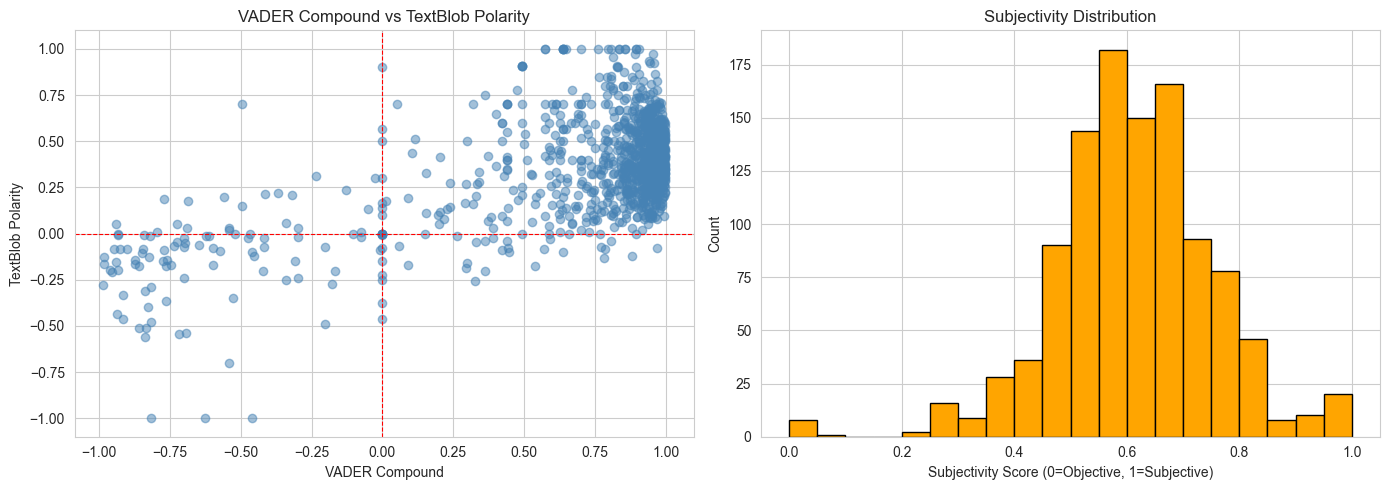


Comparison chart saved!
Results saved to 'sentiment_results.csv' | Shape: (1087, 23)


In [98]:
df = textblob_analysis(df)
compare_sentiment(df)
save_results(df)